<a href="https://colab.research.google.com/github/lithikaneelakandan56-ctrl/ml_practice/blob/main/ML/day03_regression_model_benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
''' Comparative Analysis of Regression Algorithms

## Objective
To develop and compare different regression algorithms using
a structured machine learning workflow.

## Algorithms
1. Linear Regression
2. Ridge Regression
3. Lasso Regression

## Evaluation Metrics
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

## Dataset
Scikit-learn Diabetes Dataset'''

In [2]:
#Dataset loading and exploration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
dataset = load_diabetes()
df = pd.DataFrame(dataset.data,columns=dataset.feature_names)
y = pd.Series(dataset.target, name="target")
df["target"] = y
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
# explore the data
print("Dataset shape:", df.shape)
print("\nDataset information:")
print(df.info())
print("\nStatistical summary:")
print(df.describe())
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (442, 11)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
None

Statistical summary:
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02

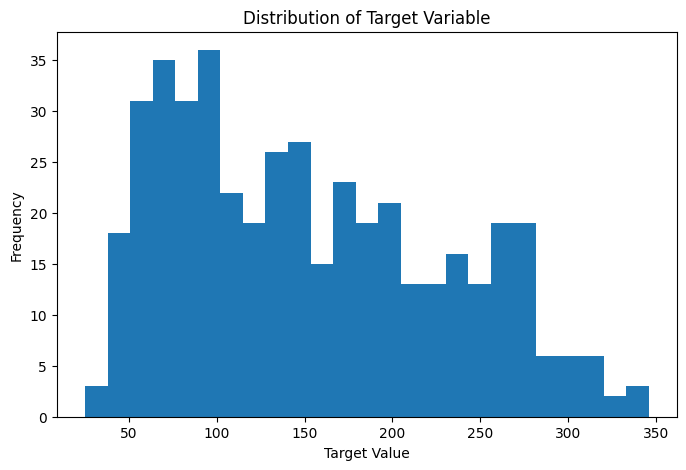

In [4]:
#EDA (Exploratory Data Analysis)
plt.figure(figsize=(8, 5))
plt.hist(y, bins=25)
plt.xlabel("Target Value")
plt.ylabel("Frequency")
plt.title("Distribution of Target Variable")
plt.show()

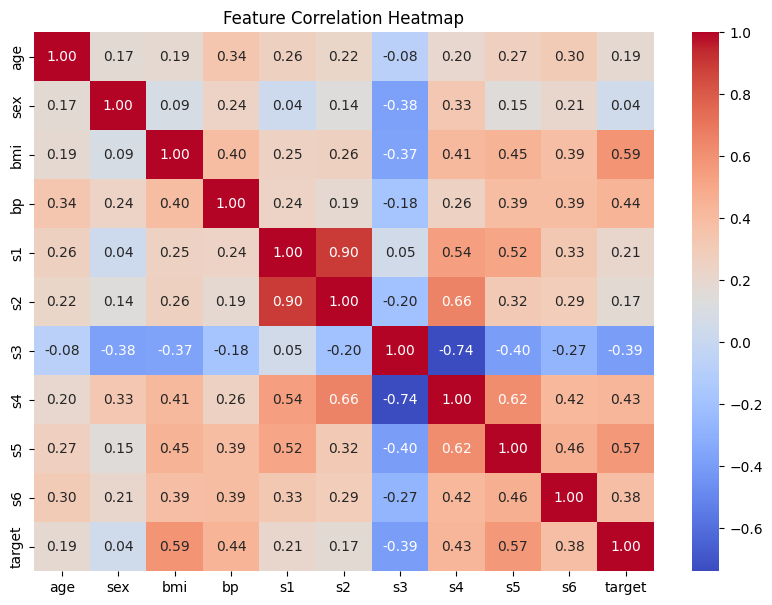

In [5]:
#feature correlation
import seaborn as sns
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

In [6]:
# Data Preparation
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (353, 10)
Testing samples: (89, 10)


In [7]:
# Model Development
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
models = {"Linear Regression": LinearRegression(),"Ridge Regression": Ridge(alpha=1.0),"Lasso Regression": Lasso(alpha=0.1)}

In [8]:
trained_models = {}
for name, algorithm in models.items():
    pipeline = Pipeline([("scaler", StandardScaler()),("model", algorithm)])
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline
    print(name, "trained successfully")

Linear Regression trained successfully
Ridge Regression trained successfully
Lasso Regression trained successfully


In [9]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
results = []
for name, model in trained_models.items():
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    results.append({"Model": name,"MAE": mae,"RMSE": rmse,"R2 Score": r2})
results_df = pd.DataFrame(results)
results_df.sort_values(by="RMSE",ascending=True)

,Model,MAE,RMSE,R2 Score
2,Lasso Regression,42.805234,53.708698,0.455541
1,Ridge Regression,42.811999,53.777454,0.454147
0,Linear Regression,42.794095,53.853446,0.452603


In [10]:
from sklearn.model_selection import cross_val_score
for name, algorithm in models.items():
    pipeline = Pipeline([("scaler", StandardScaler()),("model", algorithm)])
    scores = cross_val_score(pipeline,X_train,y_train,cv=5,scoring="r2")
    print("\n", name)
    print("Fold scores:", scores)
    print("Mean R2:", scores.mean())


 Linear Regression
Fold scores: [0.54760189 0.36123934 0.50481226 0.61773622 0.21489265]
Mean R2: 0.44925647412212155

 Ridge Regression
Fold scores: [0.54462267 0.36654273 0.50288242 0.61598841 0.22629512]
Mean R2: 0.451266270927983

 Lasso Regression
Fold scores: [0.54316931 0.36943166 0.50309021 0.61555558 0.22521482]
Mean R2: 0.45129231591542424


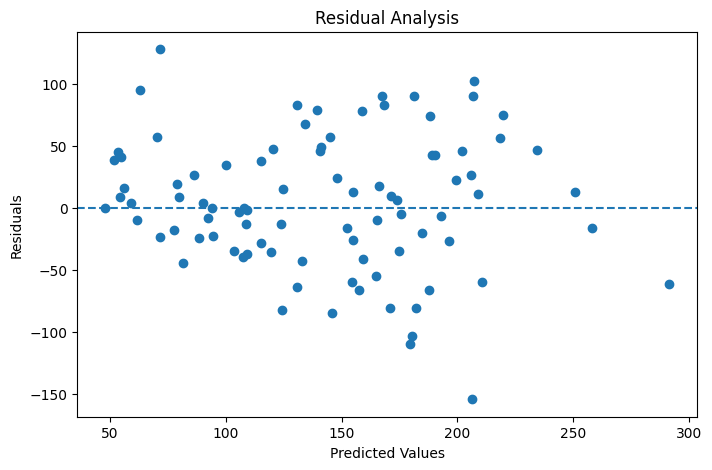

In [11]:
best_model_name = results_df.iloc[0]["Model"]
selected_model = trained_models[best_model_name]
predictions = selected_model.predict(X_test)
residuals = y_test - predictions
plt.figure(figsize=(8, 5))
plt.scatter(predictions, residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Analysis")
plt.show()